In [56]:
import numpy as np
import polars as pl

In [57]:
df = pl.read_csv('data_neural_network.csv')

Nas camadas ocultas será utilizado uma função de ativação, ReLU ou Tanh. Na camada de saída, devemos usar uma função que sirva para regressão como uma ativação linear para valores contínuos.
A função de custo para valores contínuos, regressão, usaremos o Erro Quadrático Médio.
E teremos que usar um otimizador como Adam ou SGD. É uma rede neural de regressão multiple-output pois queremos encontrar a energia e a composição e talvez outras grandezas a partir da densidade.

In [58]:
df

TRIG,density,composition,energy,density_normalized
str,f64,str,f64,f64
"""TRIG65""",0.35,"""Photon""",1.0000e14,0.001325
"""TRIG29""",3.76,"""Proton""",2.1500e15,0.014233
"""TRIG54""",20.14,"""Iron""",4.6400e15,0.076239
"""TRIG27""",0.05,"""Iron""",1.0000e14,0.000189
"""TRIG68""",1.2,"""Photon""",4.6400e14,0.004543
"""TRIG28""",2.53,"""Proton""",1.0000e15,0.009577
"""TRIG58""",9.49,"""Iron""",4.6400e15,0.035924
"""TRIG27""",1.18,"""Proton""",4.6400e14,0.004467
"""TRIG47""",10.27,"""Photon""",1.0000e15,0.038876


In [59]:
# Excluir a coluna density que não está normalizada
df = df.drop('density')
# Conversão de strings para números
mapper = {
    'Photon':1,
    'Proton':float(np.log(1)),
    'Iron':float(np.log(56))
}

trigs = []
for i in range(1,101):
    trig = 'TRIG' + str(i)
    trigs.append(trig)

trigs = dict((list(enumerate(trigs, 1))))

trigs = {value: key for key, value in trigs.items()}

df = df.with_columns(
    pl.col('composition').map_dict(mapper, default=None),
    pl.col('TRIG').map_dict(trigs, default=None)
    )

In [60]:
df_grouped = df.group_by(["energy", "composition", "TRIG"]).agg([
    pl.col("density_normalized").first()
])

In [61]:
df_neural = df_grouped.pivot(
    values="density_normalized",
    index=["energy", "composition"],
    columns="TRIG"
)
# Estrutura em ordem numérica
df_neural = df_neural.select(
    ['energy', 'composition'] + [f"{i}" for i in range(1, 101)]
)

# Log da energia
    
df_neural = df_neural.with_columns(
      ((pl.col('energy').log10()))
    )
df_neural

energy,composition,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,…,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
15.0,0.0,0.002574,0.003331,0.005186,0.005451,0.005792,0.006814,0.005224,0.004202,0.003104,0.002726,0.003748,0.004656,0.006662,0.008669,0.00988,0.009956,0.009047,0.006511,0.005565,0.003293,0.004921,0.0067,0.010448,0.015445,0.019571,0.020025,0.014725,0.009577,0.007344,0.004505,0.005224,0.008139,0.015445,0.024984,0.041526,…,0.025287,0.041261,0.040239,0.026725,0.013476,0.009123,0.005413,0.00511,0.007495,0.010296,0.014347,0.019079,0.018738,0.014347,0.008858,0.006435,0.00458,0.003937,0.00583,0.0067,0.009009,0.010183,0.011546,0.00882,0.006965,0.004694,0.00424,0.002574,0.00318,0.005035,0.005262,0.005792,0.007117,0.006435,0.004997,0.003558,0.002839
13.0,1.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.000038,…,0.000038,0.000038,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.000038,0.000038,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15.332438,0.0,0.006814,0.007987,0.009956,0.012871,0.012757,0.014006,0.012492,0.009501,0.007533,0.005792,0.007154,0.011583,0.015445,0.019079,0.021766,0.021463,0.020593,0.014271,0.012871,0.008934,0.010334,0.015255,0.02453,0.033615,0.040883,0.042775,0.031192,0.022751,0.014233,0.011318,0.012227,0.018662,0.030511,0.058864,0.088882,…,0.057955,0.085362,0.087368,0.056895,0.033274,0.020176,0.012946,0.010334,0.01499,0.025097,0.032101,0.040958,0.039066,0.034675,0.022675,0.015975,0.010561,0.008517,0.011962,0.01518,0.02029,0.023318,0.023129,0.019949,0.014574,0.012038,0.008214,0.005375,0.007874,0.009009,0.012378,0.013211,0.014536,0.012151,0.010183,0.008669,0.006322
15.666518,4.025352,0.007003,0.008934,0.010561,0.012,0.01465,0.012454,0.011205,0.010561,0.008328,0.0067,0.007987,0.011205,0.014801,0.019987,0.023205,0.022334,0.020176,0.015482,0.010675,0.007684,0.010637,0.015823,0.021539,0.030662,0.038952,0.037703,0.034448,0.023394,0.014006,0.010713,0.012151,0.020063,0.033274,0.052883,0.082258,…,0.053867,0.076542,0.07639,0.050271,0.029564,0.019495,0.011583,0.010183,0.016202,0.023545,0.03316,0.041905,0.039293,0.033047,0.022145,0.016505,0.010524,0.008063,0.011053,0.015634,0.018511,0.025552,0.021312,0.018776,0.015672,0.010751,0.00829,0.006246,0.008669,0.009615,0.013135,0.01446,0.014763,0.013173,0.011129,0.008669,0.006814
15.666518,1.0,0.020441,0.028164,0.036454,0.045312,0.051596,0.050649,0.046485,0.038498,0.029261,0.022031,0.026422,0.038914,0.054965,0.0748,0.084377,0.086346,0.076163,0.055305,0.039217,0.029489,0.037022,0.054965,0.082674,0.125639,0.159556,0.159973,0.127872,0.086611,0.053223,0.036719,0.043911,0.069955,0.124049,0.223,0.352614,…,0.218912,0.357497,0.360071,0.225234,0.127304,0.069614,0.043305,0.035242,0.05398,0.085551,0.122762,0.159367,0.16319,0.127229,0.085021,0.056706,0.034448,0.029072,0.03846,0.054321,0.072378,0.083393,0.088049,0.073589,0.054775,0.041488,0.02911,0.021691,0.028996,0.0374,0.044025,0.052731,0.051709,0.04535,0.038347,0.029375,0.02328
15.0,1.0,0.003255,0.003785,0.004353,0.005943,0.006587,0.00617,0.005224,0.00458,0.00405,0.002536,0.003899,0.004997,0.007117,0.008139,0.011811,0.00988,0.008479,0.006965,0.005148,0.004278,0.004618,0.007647,0.009804,0.015785,0.020593,0.018662,0.014006,0.010296,0.007647,0.004391,0.00511,0.008858,0.014423,0.024984,0.040164,…,0.026385,0.041791,0.040429,0.026271,0.016126,0.009842,0.005905,0.004088,0.007457,0.010902,0.014688,0.019987,0.0187,0.01446,0.011243,0.007684,0.004505,0.003823,0.00564,0.006284

In [62]:
df.filter((pl.col('composition') == 1.0) & (pl.col('energy') == 1.0000e14))

TRIG,composition,energy,density_normalized
i64,f64,f64,f64
65,1.0,1.0000e14,0.001325
76,1.0,1.0000e14,0.000719
98,1.0,1.0000e14,0.000151
79,1.0,1.0000e14,0.000379
68,1.0,1.0000e14,0.000227
20,1.0,1.0000e14,0.000189
53,1.0,1.0000e14,0.000606
85,1.0,1.0000e14,0.000379
69,1.0,1.0000e14,0.000341


In [63]:
columns = ['energy','composition']
y = df_neural.select(columns)
x = df_neural.select(pl.exclude(columns))

x = np.array(x)
y = np.array(y)

In [64]:
# Criação do modelo

import torch
import torch.nn as nn
import torch.optim as optim

# Arquitetura

class NeuralNetwork(nn.Module):
    def __init__(self, input_size, activation):
        super(NeuralNetwork, self).__init__()
    
        # Camadas
        self.hidden1 = nn.Linear(input_size, 64) # Primeira camada oculta
        self.hidden2 = nn.Linear(64,64) # Segunda camada oculta
        self.hidden3 = nn.Linear(64,32) # Terceira camada oculta
        self.output = nn.Linear(32,2) # Camada de saída com 2 valores contínuos
        self.activation = activation

    # Feed-forward com ativação ReLU
#    def forward(self,x):
#        x = torch.relu(self.hidden1(x))
#        x = torch.relu(self.hidden2(x))
#        x = self.output(x)
#        return x

    # Feed-forward com ativação tanh
#    def forward(self,x):
#        x = torch.tanh(self.hidden1(x))
#        x = torch.tanh(self.hidden2(x))
#        x = torch.tanh(self.hidden3(x))
#        x = self.output(x)
#        return x

    def forward(self,x):
        x = self.activation(self.hidden1(x))
        x = self.activation(self.hidden2(x))
        x = self.activation(self.hidden3(x))
        x = self.output(x)
        return x

In [65]:
# Treinamento do modelo

def train_model(activation_function):
    # Define a função de ativação
    if activation_function == 'tanh':
        activation = torch.tanh
    elif activation_function == 'relu':
        activation = torch.relu
    elif activation_function == 'sigmoid':
        activation = torch.sigmoid

    
    input_size = 100
    model = NeuralNetwork(input_size, activation)

    # Função perda - Erro quadrático médio

    criterion = nn.MSELoss() 

    # Otimizador Adam (Adaptive Moment Estimation)
    optimizer = optim.Adam(model.parameters(), lr = 0.001)

    loss_list = []

    x_train_tensor = torch.tensor(x, dtype= torch.float32)
    y_train_tensor = torch.tensor(y, dtype= torch.float32)

    epochs = 10000

    for epoch in range(epochs):
        # Entra no modo de treino
        model.train()
        # Zera o gradiente
        optimizer.zero_grad()
        # Faz a predição
        outputs = model(x_train_tensor)
        # Calcula o erro
        loss = criterion(outputs, y_train_tensor)
        loss_list.append(loss.item())
        # Retropropagação
        loss.backward()
        # Atualiza os parâmetros
        optimizer.step()

        if (epoch+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
            
    return model, loss_list

Epoch [100/10000], Loss: 38.5667
Epoch [200/10000], Loss: 17.2527
Epoch [300/10000], Loss: 7.5622
Epoch [400/10000], Loss: 3.5872
Epoch [500/10000], Loss: 2.2038
Epoch [600/10000], Loss: 1.8037
Epoch [700/10000], Loss: 1.7082
Epoch [800/10000], Loss: 1.6893
Epoch [900/10000], Loss: 1.6858
Epoch [1000/10000], Loss: 1.6848
Epoch [1100/10000], Loss: 1.6838
Epoch [1200/10000], Loss: 1.6824
Epoch [1300/10000], Loss: 1.6797
Epoch [1400/10000], Loss: 1.6741
Epoch [1500/10000], Loss: 1.6572
Epoch [1600/10000], Loss: 1.5811
Epoch [1700/10000], Loss: 1.4947
Epoch [1800/10000], Loss: 1.4395
Epoch [1900/10000], Loss: 1.4221
Epoch [2000/10000], Loss: 1.4089
Epoch [2100/10000], Loss: 1.3886
Epoch [2200/10000], Loss: 1.3532
Epoch [2300/10000], Loss: 1.1668
Epoch [2400/10000], Loss: 0.8152
Epoch [2500/10000], Loss: 0.6138
Epoch [2600/10000], Loss: 0.4760
Epoch [2700/10000], Loss: 0.3392
Epoch [2800/10000], Loss: 0.2751
Epoch [2900/10000], Loss: 0.2367
Epoch [3000/10000], Loss: 0.2078
Epoch [3100/10000

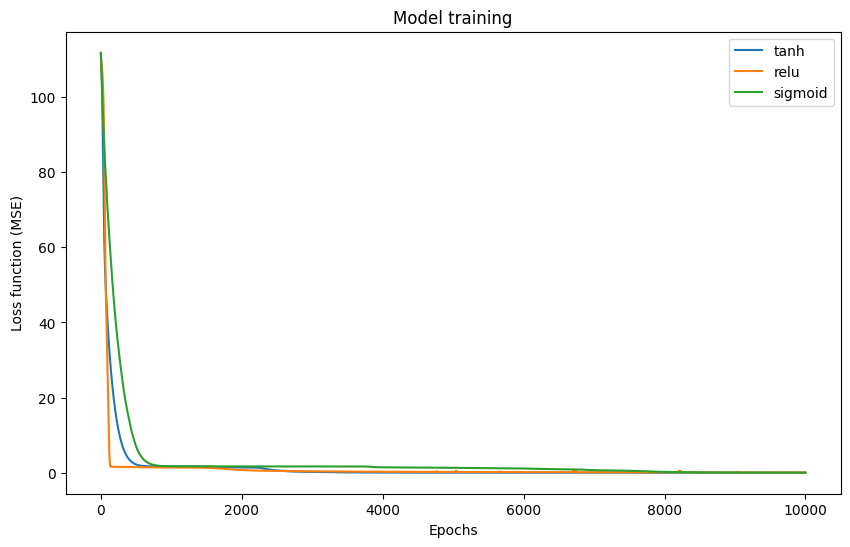

In [66]:
activation_functions = ['tanh', 'relu', 'sigmoid']
models = {}
losses = {}

for activation in activation_functions:
    #print(f'Treinando com função de ativação: {activation}')
    model, loss = train_model(activation)
    losses[activation] = loss
    models[activation] = model

import matplotlib.pyplot as plt
# Plotar os resultados
plt.figure(figsize=(10, 6))
for activation in activation_functions:
    plt.plot(losses[activation], label=activation)

plt.title('Model training')
plt.xlabel('Epochs')
plt.ylabel('Loss function (MSE)')
plt.legend()
plt.show()

In [67]:
df2 = pl.read_csv('/home/orfei/mestrado/progs/data_neural_network.txt')

In [68]:
mapper = {
    'Photon':1,
    'Proton':float(np.log(1)),
    'Iron':float(np.log(56))
}

trigs = []
for i in range(1,101):
    trig = 'TRIG' + str(i)
    trigs.append(trig)

trigs = dict((list(enumerate(trigs, 1))))

trigs = {value: key for key, value in trigs.items()}

df2 = df2.with_columns(
    pl.col('composition').map_dict(mapper, default=None),
    pl.col('TRIG').map_dict(trigs, default=None)
    )

df2_grouped = df2.group_by(["energy", "composition", "TRIG"]).agg([
    pl.col("density_normalized").first()
])

df2_neural = df2_grouped.pivot(
    values="density_normalized",
    index=["energy", "composition"],
    columns="TRIG"
)

df2_neural = df2_neural.with_columns(
      ((pl.col('energy').log10()))
    )

# Estrutura em ordem numérica
df2_neural = df2_neural.select(
    ['energy', 'composition'] + [f"{i}" for i in range(1, 101)]
)

In [69]:
df2_neural

energy,composition,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,…,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
14.0,1.0,0.000049,0.000068,0.000068,0.000083,0.000117,0.000076,0.000049,0.000095,0.000072,0.000049,0.000038,0.000098,0.000144,0.000129,0.00017,0.000193,0.000155,0.000106,0.000061,0.000091,0.000068,0.000091,0.000167,0.000276,0.000329,0.000261,0.000276,0.000197,0.000117,0.00011,0.000079,0.000155,0.000284,0.000367,0.000647,…,0.000416,0.000575,0.000647,0.000428,0.000246,0.000167,0.000132,0.000083,0.000083,0.000178,0.00028,0.000291,0.000288,0.000261,0.000151,0.000121,0.000079,0.000064,0.000098,0.000121,0.000106,0.000151,0.000182,0.000163,0.000087,0.000117,0.000064,0.000023,0.000079,0.000132,0.000117,0.000106,0.000098,0.000102,0.000102,0.000057,0.000038


In [70]:
columns = ['energy','composition']
y2 = df2_neural.select(columns)
x2 = df2_neural.select(pl.exclude(columns))

x2 = np.array(x2)
y2 = np.array(y2)

input_tensor = torch.tensor(x2, dtype=torch.float32)

In [75]:
# Avaliação do modelo
for activation, model in models.items():

    model.eval()

    # Previsão
    with torch.no_grad():
        prediction = model(input_tensor)
        print(f'Prediction with activation function {activation}: {prediction.numpy()}') 

Prediction with activation function tanh: [[13.725353   1.0142586]]
Prediction with activation function relu: [[13.537738    0.79097414]]
Prediction with activation function sigmoid: [[14.260204  3.489147]]
